# Here we implement the remaining evaluation methods. This notebook uses the test set with our pretrained model and implements different evaluation methods

# 1. Installments and imports

In [ ]:
!pip install logomaker

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
pip install pyranges

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 62.4 MB/s eta 0:00:00


In [ ]:
pip install logomaker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 51.3 MB/s eta 0:00:00


In [ ]:
import os
import json
import yaml
import argparse
import numpy as np
import pandas as pd
import pyranges as pr
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.checkpoint as cp
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader, random_split, WeightedRandomSampler, Subset
from tqdm.auto import tqdm
from sklearn.metrics import roc_auc_score, confusion_matrix, matthews_corrcoef
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from torch.utils.data.sampler import Sampler
from collections import defaultdict

# For sequence logo plotting
import logomaker as lm

# 2. Model Definition

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import numpy as np
import pandas as pd
import os
import random

# ------------------------
# Constants and Defaults
# ------------------------
MASK_EXPRESSION_VALUE = 0.5
NUM_NUCLEOTIDES = 5
INPUT_FEATURES = NUM_NUCLEOTIDES + 1  # DNA one-hot (5) + expression (1)

# ------------------------
# Device Setup
# ------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ------------------------
# Model Definition
# ------------------------
class BPNet(nn.Module):
    def __init__(self,
                 in_channels=INPUT_FEATURES,
                 n_layers=6,
                 n_filters=64,
                 first_layer_kernel_size=7,
                 dilation=True,
                 kernel_size=3,
                 final_kernel_size=30,
                 out_channels=1):
        super().__init__()

        # Shared stack
        self.iconv = nn.Conv1d(in_channels,
                               n_filters,
                               kernel_size=first_layer_kernel_size,
                               padding='same')
        self.irelu = nn.ReLU()
        self.rconvs = nn.ModuleList([
            nn.Conv1d(n_filters,
                      n_filters,
                      kernel_size=kernel_size,
                      dilation=2**i if dilation else 1,
                      padding='same')
            for i in range(1, n_layers + 1)
        ])
        self.rrelus = nn.ModuleList([nn.ReLU() for _ in range(n_layers)])

        # RNA‐coverage head
        self.out_conv = nn.Conv1d(n_filters,
                                  out_channels,
                                  kernel_size=final_kernel_size,
                                  padding='same')

        # DNA‐classification head: 4 logits per base (A,C,G,T)
        self.dna_classifier = nn.Conv1d(n_filters,
                                        4,
                                        kernel_size=1)

    def forward(self, x):
        # Input: (B, L, C_in) → Conv1D expects (B, C_in, L)
        x = x.transpose(1, 2)              # → (B, C_in, L)
        x = self.irelu(self.iconv(x))      # → (B, n_filters, L)

        # Residual dilated convolution stack
        for conv, relu in zip(self.rconvs, self.rrelus):
            x = x + relu(conv(x))          # → (B, n_filters, L)

        # RNA‐coverage head
        rna_logits = self.out_conv(x)      # → (B, 1, L)
        rna_logits = rna_logits.transpose(1, 2)  # → (B, L, 1)

        # DNA‐classification head
        dna_logits = self.dna_classifier(x)      # → (B, 4, L)
        dna_logits = dna_logits.transpose(1, 2)  # → (B, L, 4)

        return rna_logits, dna_logits

# ------------------------
# Dataset Classes
# ------------------------
class GenomeExpressionDataset(Dataset):
    def __init__(self, data_dir):
        data = np.load(os.path.join(data_dir, 'data.npz'))
        self.sequence = data['sequence']
        self.exp_plus = data['expressed_plus']
        self.exp_minus = data['expressed_minus']
        self.regions = pd.read_parquet(os.path.join(data_dir, 'regions.parquet'))
        self.complement = np.array([3, 2, 1, 0, 4], dtype=np.uint8)

    def __len__(self):
        return len(self.regions)

    def _one_hot(self, seq_segment):
        out = torch.zeros(len(seq_segment), NUM_NUCLEOTIDES, dtype=torch.float32)
        out.scatter_(1, torch.tensor(seq_segment, dtype=torch.long).unsqueeze(1), 1)
        return out

    def __getitem__(self, idx):
        if isinstance(idx, torch.Tensor):
            idx = idx.item()
        r = self.regions.iloc[idx]
        offset, window, strand = int(r.offset), int(r.window_size), r.strand
        seq = self.sequence[offset:offset + window]
        expr = (self.exp_plus if strand == '+' else self.exp_minus)[offset:offset + window]

        if strand == '-':
            seq = self.complement[seq[::-1].copy()]
            expr = expr[::-1].copy()

        oh = self._one_hot(seq)
        return oh, torch.tensor(expr, dtype=torch.float32)

# ------------------------
# Masked Dataset
# ------------------------
class MaskedExpressionDataset(Dataset):
    def __init__(self, base_dataset, mask_fraction=0.5, dna_fraction=0.15):
        self.base = base_dataset
        self.mask_frac = mask_fraction
        self.dna_frac = dna_fraction
        self.seq_len = len(self.base[0][0])

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x_dna, y = self.base[idx]  # x_dna: (L, 5), y: (L,)

        # RNA: contiguous span masking
        mask_rna = torch.zeros_like(y, dtype=torch.bool)
        span = max(1, int(self.seq_len * self.mask_frac))
        start = random.randint(0, self.seq_len - span)
        mask_rna[start:start + span] = True

        # DNA: random per-position masking
        mask_dna = (torch.rand(self.seq_len) < self.dna_frac)

        # Masked expression values
        y_in = y.clone()
        y_in[mask_rna] = MASK_EXPRESSION_VALUE
        x = torch.cat([x_dna, y_in.unsqueeze(-1)], dim=-1)  # (L, 6)

        # Extract DNA target base-calls from one-hot encoding
        dna_target = x_dna.argmax(dim=-1)  # shape: (L,)

        return x, y.unsqueeze(-1), mask_rna, mask_dna, dna_target


Using device: cpu


# 3. Functions

### not all functions here are necessary for the evaluation methods but I kept them, since loading them are not an issue

In [ ]:
def save_checkpoint(model, optimizer, scaler, scheduler, history, epoch, output_dir):
    """
    Save model & optimizer state, AMP scaler, scheduler, and training history.

    Args:
        model (nn.Module):         your PyTorch model
        optimizer (Optimizer):     optimizer used for training
        scaler (GradScaler):       AMP gradient scaler
        scheduler (LRScheduler):   learning‐rate scheduler
        history (dict):            training history dict
        epoch (int):               current epoch number (1‐based)
        output_dir (str):          directory to write the .pth file
    """
    os.makedirs(output_dir, exist_ok=True)
    ckpt = {
        'epoch': epoch,
        'model_state_dict':       model.state_dict(),
        'optimizer_state_dict':   optimizer.state_dict(),
        'scaler_state_dict':      scaler.state_dict(),
        'scheduler_state_dict':   scheduler.state_dict(),
        'history':                history,
    }
    path = os.path.join(output_dir, f'checkpoint_epoch_{epoch}.pth')
    torch.save(ckpt, path)
    print(f"Saved checkpoint: {path}")


def revcomp(arr):
    rc = {0:3,1:2,2:1,3:0,4:4}
    return np.array([rc[b] for b in arr[::-1]], dtype=arr.dtype)

def visualize_windows(regions, seq_flat, expr_flat, output_dir, n_random=3):
    os.makedirs(output_dir, exist_ok=True)
    L = int(regions['window_size'].iat[0])

    def save_window(idx, name):
        row    = regions.iloc[idx]
        contig = row.contig
        strand = row.strand
        start  = int(row.start)
        off    = int(row.offset)

        seq_win  = seq_flat[off:off+L]
        expr_win = expr_flat[off:off+L]
        if strand == '-':
            seq_win  = revcomp(seq_win)
            expr_win = expr_win[::-1]

        base_codes  = [4,3,2,1,0]   # N,T,G,C,A
        base_labels = ['N','T','G','C','A']
        rows = [expr_win] + [(seq_win==b).astype(int) for b in base_codes]
        labels = ['Expr'] + base_labels

        fig, ax = plt.subplots(figsize=(13,2))
        cmap = ListedColormap(['navy','yellow'])
        ax.imshow(np.vstack(rows), aspect='auto', cmap=cmap)
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels)
        ax.set_title(f"{contig}:{start}-{start+L} ({strand} strand)")
        ax.set_xlabel("Position (5'→3')")

        # correct two‐argument legend call
        legend_handles = [Patch(color='yellow'), Patch(color='navy')]
        legend_labels  = ['Expr', 'No Expr']
        ax.legend(legend_handles, legend_labels,
                  loc='upper right', bbox_to_anchor=(1.15,1.0),
                  title="Value")

        plt.tight_layout()
        fig.savefig(os.path.join(output_dir, f"window_{name}.png"))
        plt.close(fig)

    # first / middle / last
    save_window(0, 'first')
    save_window(len(regions)//2, 'middle')
    save_window(len(regions)-1, 'last')

     # random
    np.random.seed(42)
    for i, idx in enumerate(np.random.choice(len(regions), size=n_random, replace=False)):
        save_window(idx, f"random_{i}")

def visualize_histogram(regions, expr_flat, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    df = regions[['contig','start','window_size','offset']].copy()
    df['Chromosome']=df['contig']
    df['Start']     =df['start']
    df['End']       =df['start']+df['window_size']-1
    df['idx']       =df.index
    pr_w = pr.PyRanges(df[['Chromosome','Start','End','idx']])
    gff3 = pd.read_csv(regions.attrs['gff3_path'], sep='\t', comment='#',
                       names=['seqid','src','type','start','end','score','strand','phase','attr'])
    exon_df = (gff3.query("type=='exon'")
                  .assign(Chromosome='chr'+gff3.seqid)
                  [['Chromosome','start','end']]
                  .rename(columns={'start':'Start','end':'End'}))
    pr_e = pr.PyRanges(exon_df)
    joined    = pr_w.join(pr_e)
    exon_ids  = joined.df['idx'].unique().astype(int)
    is_exon   = np.zeros(len(regions),bool); is_exon[exon_ids]=True

    offs  = regions['offset'].values.astype(int)
    L     = int(regions['window_size'].iat[0])
    total = expr_flat.shape[0]
    csum  = np.empty(total+1,dtype=int); csum[0]=0
    np.cumsum(expr_flat>0, out=csum[1:])
    counts   = csum[offs+L] - csum[offs]
    log_expr = np.log10(counts+1)

    fig, ax = plt.subplots(figsize=(6,4))
    bins = np.histogram_bin_edges(log_expr, bins=60)
    ax.hist(log_expr[~is_exon], bins=bins, alpha=0.5, label='Non-exon')
    ax.hist(log_expr[ is_exon], bins=bins, alpha=0.5, label='Exon')
    ax.axvline(1.0, linestyle='--', label='Thresh=1')
    ax.set_xlabel("log10(count+1)"); ax.set_ylabel("Windows")
    ax.legend(); plt.tight_layout()
    fig.savefig(os.path.join(output_dir,'histogram_per_window.png'))
    plt.close(fig)

def visualize_mcc(regions, expr_flat, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    offs  = regions['offset'].values.astype(int)
    L     = int(regions['window_size'].iat[0])
    total = expr_flat.shape[0]
    csum  = np.empty(total+1,dtype=int); csum[0]=0
    np.cumsum(expr_flat>0, out=csum[1:])
    counts   = csum[offs+L] - csum[offs]
    log_expr = np.log10(counts+1)

    df = regions[['contig','start','window_size','offset']].copy()
    df['Chromosome']=df['contig']; df['Start']=df['start']
    df['End']=df['start']+df['window_size']-1; df['idx']=df.index
    pr_w = pr.PyRanges(df[['Chromosome','Start','End','idx']])
    exon_df = pd.read_csv(regions.attrs['gff3_path'], sep='\t', comment='#',
                 names=['seqid','src','type','start','end','score','strand','phase','attr']
             ).query("type=='exon'")
    exon_df = (exon_df.assign(Chromosome='chr'+exon_df.seqid)
                      [['Chromosome','start','end']]
                      .rename(columns={'start':'Start','end':'End'}))
    pr_e = pr.PyRanges(exon_df)
    joined = pr_w.join(pr_e)
    is_exon= np.zeros(len(regions),bool)
    is_exon[joined.df['idx'].unique().astype(int)] = True

    np.random.seed(0)
    N      = len(regions)
    sub_n  = min(200_000,N)
    idx_sub= np.random.choice(N,sub_n,replace=False)
    lab    = is_exon[idx_sub]
    expr_s = log_expr[idx_sub]

    ths  = np.linspace(expr_s.min(), expr_s.max(), 200)
    mccs = [matthews_corrcoef(lab, expr_s>=t) for t in ths]
    best = ths[int(np.argmax(mccs))]

    fig, ax = plt.subplots(figsize=(6,4))
    ax.plot(ths, mccs, lw=2)
    ax.axvline(best, linestyle='--', label=f'Best≈{best:.2f}')
    ax.set_xlabel("Threshold"); ax.set_ylabel("MCC")
    ax.legend(); plt.tight_layout()
    fig.savefig(os.path.join(output_dir,'mcc_curve.png'))
    plt.close(fig)

def plot_epoch_curves(train, val, title, ylabel, fname, output_dir):
    epochs = np.arange(1, len(train) + 1)
    plt.figure(figsize=(8,6))
    plt.plot(epochs, train, 'o-', label='train')
    plt.plot(epochs, val,   's-', label='val')
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, fname))
    plt.close()

# ------------------------
# Sequence Logo Plotting
# ------------------------

def plot_whole_window_recon(
    idx, base_ds, regions_df, seq_flat, expr_flat,
    window_size, model, device, output_dir,
    mask_fraction=0.5, dna_fraction=0.15
):
    # 1) Load one example
    oh, rna = base_ds[idx]                              # one-hot & true coverage
    meta     = regions_df.iloc[idx].to_dict()
    L        = window_size
    g0, g1   = meta['start'], meta['start'] + L - 1
    expr_sum = int(expr_flat[meta['offset']:meta['offset']+L].sum())

    # 2) Make masks (repeat your random‐seed logic so it's reproducible per idx)
    torch.manual_seed(idx)
    span = max(1, int(L * mask_fraction))
    start = random.randint(0, L - span)
    rm = torch.zeros(L, dtype=torch.bool, device=device)
    rm[start:start+span] = True
    dm = (torch.rand(L, device=device) < dna_fraction)

    # 3) Build the masked input batch
    oh_b  = oh.unsqueeze(0).to(device)                   # (1, L, 5)
    rna_b = rna.unsqueeze(0).to(device)                  # (1, L)
    # mask out RNA
    inp = rna_b.clone()
    inp[0, rm] = 0.0
    inp = inp.unsqueeze(-1)                              # (1, L, 1)
    # mask dna channels to uniform
    ohm = oh_b.clone()
    ohm[0, dm, :] = 1.0 / ohm.size(-1)
    x = torch.cat([ohm, inp], dim=-1)                    # (1, L, 6)

    # 4) Predict
    model.eval()
    with torch.no_grad():
        rna_logits, _ = model(x)                         # (1, L, 1), (1, L, 4)
        rna_logits = rna_logits.squeeze(-1)              # (1, L)
    out1    = rna_logits[0]                              # (L,)
    target1 = rna_b[0]                                   # (L,)

    # 5) Compute CE‐loss & acc on masked positions
    loss_all = F.binary_cross_entropy_with_logits(
        out1, target1, reduction='none'
    )
    r_loss = loss_all[rm].mean().item()
    r_acc  = ( (torch.sigmoid(out1[rm]) > 0.5).float()
               == target1[rm] ).float().mean().item()
    d_loss = loss_all[dm].mean().item()
    d_acc  = ( (torch.sigmoid(out1[dm]) > 0.5).float()
               == target1[dm] ).float().mean().item()

    true_np = target1.cpu().numpy()                     # (L,)
    pred_np = torch.sigmoid(out1).cpu().numpy()         # (L,)

    # 6) *** Single‐panel Reconstruction Plot ***
    fig, ax = plt.subplots(1,1, figsize=(12,4), dpi=150)

    ax.plot(true_np,      label="True coverage", alpha=0.8)
    ax.plot(pred_np, '--', label="Reconstruction", linewidth=1)

    ax.fill_between(
        np.arange(L), 0, 1,
        where=rm.cpu().numpy(),
        color="orange", alpha=0.3,
        transform=ax.get_xaxis_transform()
    )
    ax.fill_between(
        np.arange(L), 0, 1,
        where=dm.cpu().numpy(),
        color="grey", alpha=0.3,
        transform=ax.get_xaxis_transform()
    )

    ax.set_title(
        f"{meta['contig']}:{g0}-{g1} ({meta['strand']})  |  "
        f"Total Expressed = {expr_sum} bp | "
        f"RNA‐mask Loss={r_loss:.3f}, Acc={r_acc:.2f}  |  "
        f"DNA‐mask Loss={d_loss:.3f}, Acc={d_acc:.2f}",
        fontsize=12
    )

    ax.set_xlabel("Position in window (bp)")
    ax.set_ylabel("Normalized coverage")

    # Add mask legend
    orange = Patch(facecolor="orange", alpha=0.3, label="masked RNA")
    grey   = Patch(facecolor="grey",   alpha=0.3, label="masked DNA")
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles + [orange, grey],
        labels  + [orange.get_label(), grey.get_label()],
        loc="upper left",
        frameon=False
    )

    plt.tight_layout()
    out_path = os.path.join(
        output_dir,
        f"window_{meta['contig']}_{g0}_recon.png"
    )
    fig.savefig(out_path, dpi=150)
    plt.close(fig)

def plot_base_prediction_logo(
    idx, base_ds, regions, seq_flat, model, device,
    window_size, zoom=100, subsample=1, output_path=None
):
    """
    Plot the first `zoom` bases of the model’s DNA‐base predictions
    as a Logo, with the true sequence underneath in one uniform color.
    """
    # 1) Build dummy batch
    oh, _     = base_ds[idx]
    oh         = oh.unsqueeze(0).to(device)                    # (1, L, 5)
    zero_expr  = torch.zeros((1, window_size, 1), device=device)
    x          = torch.cat([oh, zero_expr], dim=-1)            # (1, L, 6)

    # 2) Forward & grab DNA head
    model.eval()
    with torch.no_grad():
        _, dna_logits = model(x)                                # (1, L, 4)
    probs = torch.softmax(dna_logits, dim=-1)[0].cpu().numpy()  # (L, 4)

    # 3) Crop to first N bases
    N = min(window_size, zoom)
    df_logo = pd.DataFrame(
        probs[:N:subsample],
        columns=list("ACGT"),
        index=np.arange(0, N, subsample)
    )

    # 4) Draw Logo
    fig, ax = plt.subplots(figsize=(20, 4), dpi=150)
    lm.Logo(
        df_logo, ax=ax,
        color_scheme='classic',
        stack_order='big_on_top',
        fade_below=0.01,
        show_spines=False
    )
    ax.set_ylim(-0.1, 1)   # allow room for sequence letters underneath

    # 5) Title & axis labels
    meta = regions.iloc[idx].to_dict()
    g0   = meta['start']
    ax.set_title(
        f"Model DNA Base Probabilities | {meta['contig']}:{g0}-{g0+N-1} (first {N} bp)",
        fontsize=18, fontweight='bold'
    )
    ax.set_ylabel("P(base)", fontsize=14, fontweight='bold')

    # 5) draw the actual reference sequence beneath the logo
    seq = seq_flat[meta['offset']:(meta['offset'] + window_size)][:N]
    bases = [ "ACGTN"[b] for b in seq ]
    for i, base in enumerate(bases):
        ax.text(
            i, -0.05, base,
            ha='center', va='top',
            color='black',
            fontsize=12, fontweight='bold',
            clip_on=False
    )

    # 6) Explicitly choose only ~8 ticks, evenly spaced
    step = max(1, N // 8)
    tick_positions = np.arange(0, N, step)
    tick_labels    = [str(g0 + i) for i in tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', pad=8)  # give a little extra separation

    # 7) More descriptive x‐axis title
    ax.set_xlabel(
        f"Position (bp, relative to {meta['contig']}:{g0}-{g0+N-1})",
        fontsize=14, fontweight='bold',
        labelpad=12
    )

    # 8) Layout & save
    plt.subplots_adjust(bottom=0.22, left=0.05, right=0.98)
    plt.tight_layout()
    if output_path:
        fig.savefig(output_path, bbox_inches='tight')
        plt.close(fig)
    else:
        plt.show()

# ------------------------
# Non-overlapping split
# ------------------------
def make_nonoverlapping_indices(regions_df, window_size, step=None):
    """
    Select non-overlapping windows by stepping along each contig by `step` (default = window_size).
    """
    if step is None: step = window_size
    indices = []
    for chrom, grp in regions_df.groupby('contig'):
        # sort by offset
        grp = grp.sort_values('offset')
        last = -step
        for idx, row in grp.iterrows():
            off = row.offset
            if off >= last + step:
                indices.append(idx)
                last = off
    return indices

# ------------------------
# Random baseline evaluation
# ------------------------

def evaluate_and_print_table(loader, model, device, max_samples: int = 200_000):
    """
    Evaluate both your model and a stratified‐random baseline on `loader`,
    up to `max_samples` masked positions _per modality_.
    Expects loader to yield (x, y, mask_rna, mask_dna, dna_target).
    Expects model(x) -> (rna_logits, dna_logits).
    """
    model.eval()

    # accumulators
    acc = {
        'tr': [], 'pr': [],   # RNA true & pred‐prob
        'trb': [], 'prb': [], # RNA baseline probs
        'td': [], 'pd': [],   # DNA true & pred‐probs (one‐vs‐rest)
        'tdb': [], 'pdb': [], # DNA baseline
    }
    cnt = {'rna': 0, 'dna': 0}

    with torch.no_grad():
        for x, y, mask_rna, mask_dna, dna_target in loader:
            if cnt['rna'] >= max_samples and cnt['dna'] >= max_samples:
                break

            x = x.to(device)
            rna_logits, dna_logits = model(x)     # (B,L,1), (B,L,4)
            rna_logits = rna_logits.squeeze(-1).cpu().numpy()   # (B,L)
            dna_logits = dna_logits.cpu().numpy()               # (B,L,4)

            # sigmoid & softmax
            probs_rna = 1 / (1 + np.exp(-rna_logits))           # (B,L)
            p = np.exp(dna_logits)
            probs_dna = p / p.sum(axis=-1, keepdims=True)       # (B,L,4)

            truths_rna = y.cpu().squeeze(-1).numpy()             # (B,L)
            truths_dna = dna_target.cpu().numpy()                # (B,L)
            mr = mask_rna.numpy()
            md = mask_dna.numpy()

            # — RNA —
            if cnt['rna'] < max_samples:
                idxs = np.where(mr.flatten())[0]
                take = idxs[: max_samples - cnt['rna']]
                acc['tr'].append(truths_rna.flatten()[take])
                acc['pr'].append(probs_rna.flatten()[take])
                acc['trb'].append(truths_rna.flatten()[take])
                acc['prb'].append(np.random.rand(len(take)))
                cnt['rna'] += len(take)

            # — DNA —
            if cnt['dna'] < max_samples:
                idxs = np.where(md.flatten())[0]
                take = idxs[: max_samples - cnt['dna']]
                flat_truth = truths_dna.flatten()[take]
                flat_prob  = probs_dna.reshape(-1, 4)[take]
                acc['td'].append(flat_truth)
                acc['pd'].append(flat_prob)
                rb = np.random.rand(len(take), 4)
                rb = rb / rb.sum(axis=1, keepdims=True)
                acc['tdb'].append(flat_truth)
                acc['pdb'].append(rb)
                cnt['dna'] += len(take)

    # concatenate
    def _cat(k): return np.concatenate(acc[k], axis=0)
    tr, pr, trb, prb = _cat('tr'), _cat('pr'), _cat('trb'), _cat('prb')
    td, pd, tdb, pdb = _cat('td'), _cat('pd'), _cat('tdb'), _cat('pdb')

    # predictions
    pred_rna    = (pr >= 0.5).astype(int)
    pred_rna_rb = (prb >= 0.5).astype(int)
    pred_dna    = pd.argmax(axis=1)
    pred_dna_rb = pdb.argmax(axis=1)

    # — Model metrics —
    r_loss = log_loss(tr, pr)
    r_acc  = accuracy_score(tr, pred_rna)
    r_f1   = f1_score(tr, pred_rna, average='weighted')
    r_auc  = roc_auc_score(tr, pr)

    d_loss = log_loss(td, pd, labels=[0,1,2,3])
    d_acc  = accuracy_score(td, pred_dna)
    d_f1   = f1_score(td, pred_dna, average='weighted')
    d_auc  = roc_auc_score(td, pd, multi_class='ovr', average='weighted')

    # — Baseline metrics —
    rb_r_loss = log_loss(trb, prb)
    rb_r_acc  = accuracy_score(trb, pred_rna_rb)
    rb_r_f1   = f1_score(trb, pred_rna_rb, average='weighted')
    rb_r_auc  = roc_auc_score(trb, prb)

    rb_d_loss = log_loss(tdb, pdb, labels=[0,1,2,3])
    rb_d_acc  = accuracy_score(tdb, pred_dna_rb)
    rb_d_f1   = f1_score(tdb, pred_dna_rb, average='weighted')
    rb_d_auc  = roc_auc_score(tdb, pdb, multi_class='ovr', average='weighted')

    # — Print ASCII table —
    sep = "─" * 70
    print(sep)
    print("PERFORMANCE COMPARISON".center(len(sep)))
    print(sep)
    print(f"{'Metric':<30}│{'Stratified Random':^18}│{'Your BPNet(CNN) Model':^18}")
    print(sep)
    print(f"{'DNA Loss':<30}│{rb_d_loss:18.4f}│{d_loss:18.4f}") #bce
    print(f"{'DNA Accuracy':<30}│{rb_d_acc:18.4f}│{d_acc:18.4f}")
    print(f"{'DNA F1-score (wtd)':<30}│{rb_d_f1:18.4f}│{d_f1:18.4f}")
    print(f"{'DNA ROC AUC':<30}│{rb_d_auc:18.4f}│{d_auc:18.4f}")
    print(sep)
    print(f"{'RNA Loss':<30}│{rb_r_loss:18.4f}│{r_loss:18.4f}") #bce
    print(f"{'RNA Accuracy':<30}│{rb_r_acc:18.4f}│{r_acc:18.4f}")
    print(f"{'RNA F1-score (wtd)':<30}│{rb_r_f1:18.4f}│{r_f1:18.4f}")
    print(f"{'RNA ROC AUC':<30}│{rb_r_auc:18.4f}│{r_auc:18.4f}")
    print(sep)

# ------------------------
# Predict the border between expressed and not expressed
# ------------------------

def plot_expression_border(
    idx,
    base_ds,
    regions,
    seq_flat,
    expr_flat,
    model,
    device,
    window_size,
    output_path=None
):
    """
    Plot true 0/1 expression vs model P(expr),
    with shaded expressed/unexpressed bands, gridlines, boundary markers,
    full‐width title + subtitle, and a complete legend.
    """
    # ── 1) Load data ─────────────────────────────────────────────────────────────
    oh, _     = base_ds[idx]
    oh        = oh.unsqueeze(0).to(device)   # (1, L, 5)
    meta      = regions.iloc[idx].to_dict()
    start_bp  = meta['start']
    strand    = meta['strand']
    offset    = meta['offset']
    true_expr = expr_flat[offset:offset+window_size]  # (L,) ints
    L        = window_size

    # ── 2) Model prediction ─────────────────────────────────────────────────────
    dummy     = torch.zeros((1, window_size, 1), device=device)
    x         = torch.cat([oh, dummy], dim=-1)       # (1, L, 6)
    model.eval()
    with torch.no_grad():
        logits, _ = model(x)                         # (1,L,1)
    pred_p    = torch.sigmoid(logits).squeeze().cpu().numpy()

    # ── 3) Compute metrics ───────────────────────────────────────────────────────
    # BCE loss on the full window
    bce_loss  = F.binary_cross_entropy(
                    torch.from_numpy(pred_p),
                    torch.from_numpy(true_expr).float()
                ).item()
    pred_bin  = (pred_p > 0.5).astype(int)
    acc       = (pred_bin == true_expr).mean()
    # find boundary flips
    flips     = np.where(np.diff(true_expr) != 0)[0] + 1
    n_flip    = len(flips)
    total_exp = int(true_expr.sum())

    # ── 4) Build plot ──────────────────────────────────────────────────────────
    fig, ax = plt.subplots(
        figsize=(14, 4),
        dpi=150,
        gridspec_kw={'top': 0.80}          # leave room for title+subtitle
    )

    # a) shaded expressed/unexpressed
    in_expr = true_expr == 1
    # group contiguous runs
    from itertools import groupby
    for val, grp in groupby(enumerate(in_expr), key=lambda x: x[1]):
        idxs = [i for i,_ in grp]
        if not idxs:
            continue
        ax.axvspan(
            idxs[0],
            idxs[-1] + 1,
            color='orange' if val else 'lightgray',
            alpha=0.25,
            zorder=0
        )

    # b) vertical grid every 200 bp
    for g in range(0, window_size, 200):
        ax.axvline(g, color='k', linestyle=':', linewidth=0.5, alpha=0.3)

    # c) true step-curve
    line_true = ax.step(
        np.arange(window_size),
        true_expr,
        where='post',
        color='black',
        linewidth=2,
        label='True expr (0/1)',
        zorder=2
    )[0]

    # d) model probability
    line_pred = ax.plot(
        np.arange(window_size),
        pred_p,
        '--',
        color='green',
        linewidth=1.8,
        label='Model P(expr)',
        zorder=3
    )[0]

    # e) boundary markers
    for f in flips:
        ax.axvline(f, color='red', linestyle='--', linewidth=1.2, zorder=4)

    boundary_line = Line2D([0], [0], color='red', linestyle='--', label='True expression boundary')

    # ── 5) Titles & subtitle ────────────────────────────────────────────────────
    contig = meta['contig']
    main_title = (
        f"Expression-Boundary Prediction   |   {contig}:{start_bp}-{start_bp+window_size-1} ({strand})"
    )
    subtitle   = (
        f"Loss = {bce_loss:.3f}   |   Acc = {acc:.3f}   |   "
        f"Total expressed = {total_exp} bp   |   Boundaries = {n_flip}"
    )
    # top‐line title
    ax.set_title(main_title, fontsize=18, fontweight='bold', pad=14)
    # subtitle above plot
    fig.text(
        0.50, 0.91, subtitle,
        ha='center', va='center',
        fontsize=12, color='dimgray'
    )

    # ── 6) Axes labels ──────────────────────────────────────────────────────────
    ax.set_xlabel(
        f"Genomic coordinate: {start_bp} → {start_bp+L-1}  (window length = {L} bp)",
        fontsize=14, fontweight='bold', labelpad=12
    )
    ax.set_ylabel(
        "Coverage / P(expr)",
        fontsize=14, fontweight='bold'
    )
    ax.set_xlim(0, window_size)

    # ── 7) Legend ───────────────────────────────────────────────────────────────
    expr_patch = Patch(facecolor='orange', alpha=0.25, label='Expressed region')
    noexpr_patch = Patch(facecolor='lightgray', alpha=0.25, label='Unexpressed region')
    legend_handles = [line_true, line_pred, expr_patch, noexpr_patch, boundary_line]
    legend_labels  = ['True Expressed(0/1)', 'Model Pred(Expressed)', 'Expressed Region', 'Unexpressed Region', 'True Boundary']
    ax.legend(handles=legend_handles,
            labels=legend_labels,
            loc='upper left',
            frameon=False,
            fontsize=11,
            title="Legend",
            title_fontsize=12
    )

    plt.tight_layout()

    if output_path:
        fig.savefig(output_path, bbox_inches='tight')
        plt.close(fig)
    else:
        plt.show()


In [ ]:
import torch
import torch.nn.functional as F
from torch.cuda.amp import autocast
from tqdm import tqdm
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score

# ------------------------
# Training & Evaluation Loops
# ------------------------

def train_loop(model, loader, optimizer, scaler, scheduler=None):
    """
    Training loop for BPNet model with RNA and DNA heads.

    Expects loader to yield:
        x          : (B, L, 6) float32
        y          : (B, L, 1) float32   — RNA coverage (0/1)
        mask_rna   : (B, L)    bool      — which positions to mask for RNA loss
        mask_dna   : (B, L)    bool      — which positions to mask for DNA loss
        dna_target : (B, L)    long      — true nucleotide (0–3) at each position

    Returns dictionary of average losses, accuracy, F1 and AUC on masked positions.
    """
    model.train()
    stats = {
        'rna_loss': 0.0, 'correct_rna': 0, 'n_rna': 0,
        'dna_loss': 0.0, 'correct_dna': 0, 'n_dna': 0,
    }
    all_tr, all_pr, all_pred_r = [], [], []
    all_td, all_pd_full, all_pred_d = [], [], []

    for x, y, mask_rna, mask_dna, dna_target in tqdm(loader, desc="Train batches"):
        x, y = x.to(device), y.to(device)
        mask_rna = mask_rna.to(device)
        mask_dna = mask_dna.to(device)
        dna_target = dna_target.to(device)

        # Mask DNA input by setting one-hot to uniform (0.25) at masked positions
        x_masked = x.clone()
        x_masked[..., :4][mask_dna] = 0.25

        optimizer.zero_grad()
        with autocast(device_type='cuda'):
            rna_logits, dna_logits = model(x_masked)
            rna_logits = rna_logits.squeeze(-1)

            loss_rna_all = F.binary_cross_entropy_with_logits(
                rna_logits, y.squeeze(-1), reduction='none'
            )
            loss_dna_all = F.cross_entropy(
                dna_logits.permute(0, 2, 1),
                dna_target,
                reduction='none'
            )

            loss_rna = loss_rna_all[mask_rna].mean() if mask_rna.any() else torch.tensor(0., device=device)
            loss_dna = loss_dna_all[mask_dna].mean() if mask_dna.any() else torch.tensor(0., device=device)
            loss = 0.5 * (loss_rna + loss_dna)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        if scheduler is not None:
            scheduler.step()

        # Accumulate RNA metrics
        n_r = int(mask_rna.sum())
        if n_r:
            stats['n_rna'] += n_r
            stats['rna_loss'] += loss_rna.item() * n_r

            prob_r = torch.sigmoid(rna_logits)[mask_rna].detach().cpu().numpy()
            pred_r = (prob_r > 0.5).astype(int)
            true_r = y.squeeze(-1)[mask_rna].detach().cpu().numpy().astype(int)

            stats['correct_rna'] += (pred_r == true_r).sum()
            all_tr.extend(true_r.tolist())
            all_pr.extend(prob_r.tolist())
            all_pred_r.extend(pred_r.tolist())

        # Accumulate DNA metrics
        n_d = int(mask_dna.sum())
        if n_d:
            stats['n_dna'] += n_d
            stats['dna_loss'] += loss_dna.item() * n_d

            soft = torch.softmax(dna_logits, dim=-1)
            pd = soft[mask_dna]
            td = dna_target[mask_dna]

            pd_np = pd.detach().cpu().numpy()
            td_np = td.detach().cpu().numpy().astype(int)
            pred_d = pd_np.argmax(-1)

            stats['correct_dna'] += (pred_d == td_np).sum()
            all_td.extend(td_np.tolist())
            all_pd_full.append(pd_np)
            all_pred_d.extend(pred_d.tolist())

    # Final RNA stats
    rna_loss = stats['rna_loss'] / stats['n_rna']
    rna_acc = stats['correct_rna'] / stats['n_rna']
    rna_f1 = f1_score(all_tr, all_pred_r, average='weighted')
    rna_auc = roc_auc_score(all_tr, all_pr)

    # Final DNA stats
    dna_loss = stats['dna_loss'] / stats['n_dna']
    dna_acc = stats['correct_dna'] / stats['n_dna']
    dna_f1 = f1_score(all_td, all_pred_d, average='weighted')

    if all_pd_full:
        all_pd_full = np.vstack(all_pd_full)
        try:
            dna_auc = roc_auc_score(all_td, all_pd_full, multi_class='ovr', average='weighted')
        except ValueError:
            dna_auc = None
    else:
        dna_auc = None

    total_m = stats['n_rna'] + stats['n_dna']
    total_loss = (stats['rna_loss'] + stats['dna_loss']) / total_m
    total_acc = (stats['correct_rna'] + stats['correct_dna']) / total_m

    return {
        'rna_loss': rna_loss, 'rna_acc': rna_acc,
        'rna_f1': rna_f1, 'rna_auc': rna_auc,
        'dna_loss': dna_loss, 'dna_acc': dna_acc,
        'dna_f1': dna_f1, 'dna_auc': dna_auc,
        'total_loss': total_loss, 'total_acc': total_acc
    }

def eval_loop(model, loader):
    """
    Evaluation loop — same metrics as training, but no gradient updates.
    """
    model.eval()
    stats = {
        'rna_loss': 0.0, 'correct_rna': 0, 'n_rna': 0,
        'dna_loss': 0.0, 'correct_dna': 0, 'n_dna': 0,
    }
    all_tr, all_pr, all_pred_r = [], [], []
    all_td, all_pd_full, all_pred_d = [], [], []

    with torch.no_grad():
        for x, y, mask_rna, mask_dna, dna_target in tqdm(loader, desc="Val batches"):
            x, y = x.to(device), y.to(device)
            mask_rna = mask_rna.to(device)
            mask_dna = mask_dna.to(device)
            dna_target = dna_target.to(device)

            x_masked = x.clone()
            x_masked[..., :4][mask_dna] = 0.25

            rna_logits, dna_logits = model(x_masked)
            rna_logits = rna_logits.squeeze(-1)

            loss_all_rna = F.binary_cross_entropy_with_logits(
                rna_logits, y.squeeze(-1), reduction='none'
            )
            loss_all_dna = F.cross_entropy(
                dna_logits.permute(0, 2, 1),
                dna_target,
                reduction='none'
            )

            # RNA metrics
            n_r = int(mask_rna.sum())
            if n_r:
                lr = loss_all_rna[mask_rna].mean()
                stats['n_rna'] += n_r
                stats['rna_loss'] += lr.item() * n_r

                pr = torch.sigmoid(rna_logits)[mask_rna].detach().cpu().numpy()
                pd = (pr > 0.5).astype(int)
                tr = y.squeeze(-1)[mask_rna].detach().cpu().numpy().astype(int)

                stats['correct_rna'] += (pd == tr).sum()
                all_tr.extend(tr.tolist())
                all_pr.extend(pr.tolist())
                all_pred_r.extend(pd.tolist())

            # DNA metrics
            n_d = int(mask_dna.sum())
            if n_d:
                ld = loss_all_dna[mask_dna].mean()
                stats['n_dna'] += n_d
                stats['dna_loss'] += ld.item() * n_d

                soft = torch.softmax(dna_logits, dim=-1)
                pd = soft[mask_dna]
                td = dna_target[mask_dna]

                pd_np = pd.detach().cpu().numpy()
                td_np = td.detach().cpu().numpy().astype(int)
                prd = pd_np.argmax(-1)

                stats['correct_dna'] += (prd == td_np).sum()
                all_td.extend(td_np.tolist())
                all_pd_full.append(pd_np)
                all_pred_d.extend(prd.tolist())

    # RNA finalize
    rna_loss = stats['rna_loss'] / stats['n_rna']
    rna_acc = stats['correct_rna'] / stats['n_rna']
    rna_f1 = f1_score(all_tr, all_pred_r, average='weighted')
    rna_auc = roc_auc_score(all_tr, all_pr)

    # DNA finalize
    dna_loss = stats['dna_loss'] / stats['n_dna']
    dna_acc = stats['correct_dna'] / stats['n_dna']
    dna_f1 = f1_score(all_td, all_pred_d, average='weighted')

    if all_pd_full:
        all_pd_full = np.vstack(all_pd_full)
        try:
            dna_auc = roc_auc_score(all_td, all_pd_full, multi_class='ovr', average='weighted')
        except ValueError:
            dna_auc = None
    else:
        dna_auc = None

    total_m = stats['n_rna'] + stats['n_dna']
    total_loss = (stats['rna_loss'] + stats['dna_loss']) / total_m
    total_acc = (stats['correct_rna'] + stats['correct_dna']) / total_m

    return {
        'rna_loss': rna_loss, 'rna_acc': rna_acc,
        'rna_f1': rna_f1, 'rna_auc': rna_auc,
        'dna_loss': dna_loss, 'dna_acc': dna_acc,
        'dna_f1': dna_f1, 'dna_auc': dna_auc,
        'total_loss': total_loss, 'total_acc': total_acc
    }


In [ ]:
# ------------------------
# Main
# ------------------------

data_dir = 'provided_data'
output_dir = 'output'
os.makedirs(output_dir, exist_ok=True)

# -- Load base dataset & regions
base_ds   = GenomeExpressionDataset(data_dir)
regions   = base_ds.regions
data_npz  = np.load(os.path.join(data_dir, 'data.npz'))
seq_flat  = data_npz['sequence']
expr_flat = (data_npz['expressed_plus'] > 0).astype(int)
window_size = regions['window_size'].iat[0]

# -- Load or build non-overlap & train/val idxs
nonoverlap_path = os.path.join(output_dir, 'nonoverlap_idxs.txt')
trainval_path   = os.path.join(output_dir, 'trainval_idxs.txt')

if os.path.exists(trainval_path):
    # assume both files exist, just read the post-exclusion list
    print("Reading precomputed train/val indices…")
    with open(trainval_path) as f:
        good_idxs = [int(line.strip()) for line in f]
else:
    # first time: build & save both
    print("Building non-overlap indices…")
    good_idxs = make_nonoverlapping_indices(regions, window_size)
    with open(nonoverlap_path,'w') as f:
        for i in good_idxs:
            f.write(f"{i}\n")
    print(f"→ Wrote {len(good_idxs)} non-overlap idxs to {nonoverlap_path}")

    # exclude the two held-out regions
    exclude_mask = (
      ((regions.contig=='chrIV') & (regions.start>=1468900)&(regions.start<1469900))|
      ((regions.contig=='chrIX') & (regions.start>=47250)  &(regions.start<48250))
    )
    exclude_idxs = regions[exclude_mask].index.tolist()
    good_idxs = [i for i in good_idxs if i not in exclude_idxs]

    with open(trainval_path,'w') as f:
        for i in good_idxs:
            f.write(f"{i}\n")
    print(f"→ Wrote {len(good_idxs)} post-exclusion idxs to {trainval_path}")

# now sub_regions and DataLoader as before
sub_regions = regions.loc[good_idxs].reset_index(drop=True)

masked_ds = MaskedExpressionDataset(base_ds,
                                    mask_fraction=0.5,
                                    dna_fraction=0.15)
print(f"Masked dataset wraps base dataset of length {len(masked_ds)}")

# select exactly those base-dataset indices
torch.manual_seed(0)
base_indices = torch.tensor(good_idxs, dtype=torch.long)

# hyper-parameters
DROPOUT = 0.1  # Unused currently

# DEBUG_DATASET_SIZE = len(masked_ds) // 2    # e.g. small size for debugging (e.g. 20000), whole dataset: None
DEBUG_DATASET_SIZE = None

# training defaults
BATCH_SIZE = 128
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
NUM_EPOCHS = 50
GRAD_ACCUM_STEPS = 4
WARMUP_STEPS = 3000
VAL_FRACTION = 0.1
TEST_FRACTION = 0.1
TRAIN_FRACTION = 1 - VAL_FRACTION - TEST_FRACTION
NUM_WORKERS = 4

# if you want a debug subset, else use all:
if DEBUG_DATASET_SIZE is not None:
    # pick a random subset of the non-overlapping indices
    print(f"Subsampling {DEBUG_DATASET_SIZE} windows for debugging...")
    perm = torch.randperm(len(base_indices))
    sel_indices = base_indices[perm[:DEBUG_DATASET_SIZE]].tolist()
else:
    sel_indices = base_indices.tolist()
print(f"Using {len(sel_indices)} windows in ds (dataset)")

ds = Subset(masked_ds, sel_indices)

# Split into train/val/test
N       = len(ds)
n_train = int(TRAIN_FRACTION * N)
n_val   = int(VAL_FRACTION   * N)
n_test  = N - n_train - n_val
print(f"Splitting: train={n_train}, val={n_val}, test={n_test}")

train_ds, val_ds, test_ds = random_split(
    ds, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                            num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                            num_workers=NUM_WORKERS, pin_memory=True)

# -- Model, optimizer, scheduler
model     = BPNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scaler    = GradScaler(enabled=torch.cuda.is_available())
scheduler = optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda step: min(1.0, step / WARMUP_STEPS)
)

# -- History containers
history = defaultdict(list)

# -- Training loop
for epoch in range(1, NUM_EPOCHS + 1):
    print(f"=== Epoch {epoch}/{NUM_EPOCHS} ===")
    tr = train_loop(model, train_loader, optimizer, scaler, scheduler)
    vl = eval_loop(model, val_loader)

    # record metrics
    for k, v in tr.items():
        history[f"train_{k}"].append(v)
    for k, v in vl.items():
        history[f"val_{k}"].append(v)

    print(
        f"Ep{epoch} | "
        f"RNA L={tr['rna_loss']:.4f}, A={tr['rna_acc']:.3f} | "
        f"DNA L={tr['dna_loss']:.4f}, A={tr['dna_acc']:.3f} || "
        f"Val RNA L={vl['rna_loss']:.4f}, A={vl['rna_acc']:.3f} | "
        f"DNA L={vl['dna_loss']:.4f}, A={vl['dna_acc']:.3f}"
    )
    save_checkpoint(model, optimizer, scaler, scheduler, history, epoch, output_dir)

# -- Save history
with open(os.path.join(output_dir, 'history.json'), 'w') as f:
    json.dump(history, f, indent=2)


Building non-overlapping indices...


KeyboardInterrupt: 

# 4. Evaluation methods

In [ ]:
import random
import torch
from torch.utils.data import DataLoader, Subset, random_split
from google.colab import drive
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
from sklearn.calibration import calibration_curve

## Loading data & variables

In [ ]:
# Loading the data using Google Drive
drive.mount('/content/gdrive')
google_drive_project_path = '/content/gdrive/MyDrive/DnARnAProject/'
data_dir = os.path.join(google_drive_project_path, 'data/')

Mounted at /content/gdrive


In [ ]:
# Load base dataset
base_ds = GenomeExpressionDataset(data_dir)
print(f"Loaded {len(base_ds)} windows total")

regions = base_ds.regions
exclude = (
    ((regions.contig=='chrIV') & (regions.start>=1468900)&(regions.start<1469900)) |
    ((regions.contig=='chrIX') & (regions.start>=  47250)&(regions.start< 48250))
)

Loaded 15705825 windows total


In [ ]:
exclude_idxs = set(regions[exclude].index.tolist())

In [ ]:
all_indices = [i for i in range(len(base_ds)) if i not in exclude_idxs]

In [ ]:
DEBUG_DATASET_SIZE = len(base_ds) // 60  # 261712
random.seed(0)
all_indices = random.sample(all_indices, DEBUG_DATASET_SIZE)

In [ ]:
contigs = [regions.at[i, 'contig'] for i in all_indices]
unique_chroms = sorted(set(contigs))

random.seed(0)
random.shuffle(unique_chroms)

# based on your teammate’s printout
train_chroms = ['chrVIII', 'chrXV', 'chrI', 'chrXIV', 'chrVII', 'chrV', 'chrXIII', 'chrIX',
                'chrXVI', 'chrXII', 'chrII', 'chrX', 'chrM']
val_chroms   = ['chrIV']
test_chroms  = ['chrXI', 'chrIII', 'chrVI']

train_idxs = [i for i in all_indices if regions.at[i, 'contig'] in train_chroms]
val_idxs   = [i for i in all_indices if regions.at[i, 'contig'] in val_chroms]
test_idxs  = [i for i in all_indices if regions.at[i, 'contig'] in test_chroms]

In [ ]:
test_ds = MaskedExpressionDataset(base_ds, mask_fraction=0.5, dna_fraction=0.15)

test_loader = DataLoader(
    Subset(test_ds, test_idxs),
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
# Checking architecture
batch = next(iter(test_loader))
print(f"Length of batch: {len(batch)}")
for i, item in enumerate(batch):
    print(f"Item {i}: shape = {item.shape}")


Length of batch: 5
Item 0: shape = torch.Size([128, 2048, 6])
Item 1: shape = torch.Size([128, 2048, 1])
Item 2: shape = torch.Size([128, 2048])
Item 3: shape = torch.Size([128, 2048])
Item 4: shape = torch.Size([128, 2048])


In [ ]:
model = BPNet()
model.to(device)

BPNet(
  (iconv): Conv1d(6, 64, kernel_size=(7,), stride=(1,), padding=same)
  (irelu): ReLU()
  (rconvs): ModuleList(
    (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=same, dilation=(2,))
    (1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=same, dilation=(4,))
    (2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=same, dilation=(8,))
    (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=same, dilation=(16,))
    (4): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=same, dilation=(32,))
    (5): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=same, dilation=(64,))
  )
  (rrelus): ModuleList(
    (0-5): 6 x ReLU()
  )
  (out_conv): Conv1d(64, 1, kernel_size=(30,), stride=(1,), padding=same)
  (dna_classifier): Conv1d(64, 4, kernel_size=(1,), stride=(1,))
)

In [ ]:
# Loading the model state from pretrained model
checkpoint = torch.load("best.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

## Random guessing

### RNA model vs random guessing

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score
import torch.nn.functional as F

def evaluate_rna_model_vs_random(model, test_loader, device):
    model.eval()
    all_preds_model, all_targets, all_probs_model = [], [], []
    all_preds_random, all_probs_random = [], []
    total_loss_model, total_loss_random = 0.0, 0.0
    total_masked = 0

    with torch.no_grad():
        for x, y, mask_rna, _ in test_loader:
            x = x.to(device)
            y = y.to(device).squeeze(-1)          # [B, L]
            mask_rna = mask_rna.to(device)        # [B, L]

            logits = model(x).squeeze(-1)         # [B, L]
            probs_model = torch.sigmoid(logits)

            targets = y[mask_rna]
            probs_model_masked = probs_model[mask_rna]
            logits_masked = logits[mask_rna]

            # --- Model ---
            preds_model = (probs_model_masked >= 0.5).long()
            loss_model = F.binary_cross_entropy_with_logits(logits_masked, targets.float(), reduction='sum')

            # --- Random Guessing ---
            probs_random = torch.rand_like(probs_model_masked)
            preds_random = (probs_random >= 0.5).long()
            loss_random = F.binary_cross_entropy(probs_random, targets.float(), reduction='sum')

            # Collect
            all_preds_model.extend(preds_model.cpu().numpy())
            all_probs_model.extend(probs_model_masked.cpu().numpy())
            all_preds_random.extend(preds_random.cpu().numpy())
            all_probs_random.extend(probs_random.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

            total_loss_model += loss_model.item()
            total_loss_random += loss_random.item()
            total_masked += targets.numel()

    # --- Metrics ---
    acc_model = sum([p == t for p, t in zip(all_preds_model, all_targets)]) / total_masked
    acc_random = sum([p == t for p, t in zip(all_preds_random, all_targets)]) / total_masked

    f1_model = f1_score(all_targets, all_preds_model, average='weighted')
    f1_random = f1_score(all_targets, all_preds_random, average='weighted')

    try:
        auc_model = roc_auc_score(all_targets, all_probs_model)
        auc_random = roc_auc_score(all_targets, all_probs_random)
    except ValueError:
        auc_model = auc_random = float('nan')

    print("🔬 Evaluation on Masked RNA Positions")
    print(f"Model   → Accuracy: {acc_model:.4f},  BCE Loss: {total_loss_model/total_masked:.4f},  F1: {f1_model:.4f},  ROC AUC: {auc_model:.4f}")
    print(f"Random  → Accuracy: {acc_random:.4f},  BCE Loss: {total_loss_random/total_masked:.4f},  F1: {f1_random:.4f},  ROC AUC: {auc_random:.4f}")


In [ ]:
evaluate_rna_model_vs_random(model, test_loader, device)

🔬 Evaluation on Masked RNA Positions
Model   → Accuracy: 0.7101,  BCE Loss: 0.5510,  F1: 0.6825,  ROC AUC: 0.7875
Random  → Accuracy: 0.5008,  BCE Loss: 0.9999,  F1: 0.5060,  ROC AUC: 0.5001


### RNA and DNA random guessing

In [ ]:
def evaluate_rna_dna_vs_random(model, test_loader, device):
    model.eval()

    # Collectors
    rna_true, rna_pred, rna_probs_all, rna_mask = [], [], [], []
    dna_true, dna_pred, dna_mask = [], [], []
    dna_logits_all = []

    with torch.no_grad():
        for batch in test_loader:
            x, y, mask_rna, mask_dna, dna_target = batch
            x, y = x.to(device), y.to(device)
            mask_rna, mask_dna = mask_rna.to(device), mask_dna.to(device)
            dna_target = dna_target.to(device)

            outputs = model(x)
            if isinstance(outputs, tuple) and len(outputs) == 2:
                rna_logits, dna_logits = outputs
            else:
                raise ValueError("Unexpected model output format.")

            # RNA predictions
            rna_probs = torch.sigmoid(rna_logits).squeeze(-1)
            rna_preds = (rna_probs > 0.5).long()

            rna_true.append(y.squeeze(-1)[mask_rna].cpu())
            rna_pred.append(rna_preds[mask_rna].cpu())
            rna_probs_all.append(rna_probs[mask_rna].cpu())
            rna_mask.append(mask_rna.cpu())

            # DNA predictions
            dna_preds = torch.argmax(dna_logits, dim=-1)
            dna_true.append(dna_target[mask_dna].cpu())
            dna_pred.append(dna_preds[mask_dna].cpu())
            dna_mask.append(mask_dna.cpu())

            # Collect logits for CE loss
            masked_logits = dna_logits[mask_dna]      # [N_masked, 4]
            dna_logits_all.append(masked_logits.cpu())

    # -------------------
    # RNA metrics
    # -------------------
    rna_true = torch.cat(rna_true).numpy()
    rna_pred = torch.cat(rna_pred).numpy()
    rna_probs_all = torch.cat(rna_probs_all).numpy()

    rna_acc = accuracy_score(rna_true, rna_pred)
    rna_f1 = f1_score(rna_true, rna_pred, average='weighted')

    try:
        rna_auc = roc_auc_score(rna_true, rna_probs_all)
    except:
        rna_auc = float('nan')

    rna_loss = F.binary_cross_entropy(
        torch.tensor(rna_probs_all, dtype=torch.float32),
        torch.tensor(rna_true, dtype=torch.float32)
    ).item()

    # RNA random baselines
    rna_random_preds = np.random.randint(0, 2, size=len(rna_true))
    rna_random_probs = np.random.rand(len(rna_true))

    rna_random_acc = accuracy_score(rna_true, rna_random_preds)
    rna_random_f1 = f1_score(rna_true, rna_random_preds, average='weighted')
    try:
        rna_random_auc = roc_auc_score(rna_true, rna_random_probs)
    except:
        rna_random_auc = float('nan')

    rna_random_bce = F.binary_cross_entropy(
        torch.tensor(rna_random_probs, dtype=torch.float32),
        torch.tensor(rna_true, dtype=torch.float32)
    ).item()

    # -------------------
    # DNA metrics
    # -------------------
    dna_true = torch.cat(dna_true).numpy()
    dna_pred = torch.cat(dna_pred).numpy()
    dna_logits_all = torch.cat(dna_logits_all, dim=0)

    dna_acc = accuracy_score(dna_true, dna_pred)
    dna_f1 = f1_score(dna_true, dna_pred, average='weighted')

    # DNA cross-entropy loss
    dna_loss = F.cross_entropy(
        dna_logits_all,
        torch.tensor(dna_true, dtype=torch.long)
    ).item()

    # DNA random baseline
    dna_random_preds = np.random.choice([0, 1, 2, 3], size=len(dna_true))
    dna_random_acc = accuracy_score(dna_true, dna_random_preds)
    dna_random_f1 = f1_score(dna_true, dna_random_preds, average='weighted')
    random_logits = torch.full((len(dna_true), 4), fill_value=np.log(0.25))  # log-prob of uniform
    dna_random_ce = F.cross_entropy(
        random_logits,
        torch.tensor(dna_true, dtype=torch.long)
    ).item()

    # -------------------
    # Print results
    # -------------------

    print("\n🧬DNA: Our CNN vs Baseline:")
    print(f"DNA loss (CE)      = {dna_loss:.4f} (random = {dna_random_ce:.4f})")
    print(f"DNA accuracy       = {dna_acc:.4f} (random = {dna_random_acc:.4f})")
    print(f"DNA F1 (weighted)  = {dna_f1:.4f} (random = {dna_random_f1:.4f})")

    print("📊RNA: Our CNN vs Baseline:")
    print(f"RNA loss (BCE)     = {rna_loss:.4f} (random = {rna_random_bce:.4f})")
    print(f"RNA accuracy       = {rna_acc:.4f} (random = {rna_random_acc:.4f})")
    print(f"RNA F1 (weighted)  = {rna_f1:.4f} (random = {rna_random_f1:.4f})")
    print(f"RNA ROC AUC        = {rna_auc:.4f} (random = {rna_random_auc:.4f})")

    return {
        "rna": {
            "accuracy": rna_acc,
            "f1": rna_f1,
            "auc": rna_auc,
            "loss_bce": rna_loss,
            "random_accuracy": rna_random_acc,
            "random_f1": rna_random_f1,
            "random_auc": rna_random_auc,
            "random_loss_bce": rna_random_bce,
        },
        "dna": {
            "accuracy": dna_acc,
            "f1": dna_f1,
            "loss_ce": dna_loss,
            "random_accuracy": dna_random_acc,
            "random_f1": dna_random_f1,
            "random_loss_ce": dna_random_ce,
        }
    }



In [ ]:
results = evaluate_rna_dna_vs_random(model, test_loader, device)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1036.)
  return F.conv1d(


KeyboardInterrupt: 

In [ ]:
def print_results_table(results):
    print("\n📋 Evaluation Results\n")
    print("| Metric              | RNA       | RNA (Random) | DNA       | DNA (Random) |")
    print("|---------------------|-----------|--------------|-----------|--------------|")
    print(f"| Accuracy            | {results['rna']['accuracy']:.4f} | {results['rna']['random_accuracy']:.4f}    | {results['dna']['accuracy']:.4f} | {results['dna']['random_accuracy']:.4f}    |")
    print(f"| F1 Score (weighted) | {results['rna']['f1']:.4f} | {results['rna']['random_f1']:.4f}    | {results['dna']['f1']:.4f} | {results['dna']['random_f1']:.4f}    |")
    print(f"| ROC AUC             | {results['rna']['auc']:.4f} | {results['rna']['random_auc']:.4f}    |    –     |      –       |")
    print(f"| Loss (BCE/CE)       | {results['rna']['loss_bce']:.4f} | {results['rna']['random_loss_bce']:.4f}    | {results['dna']['loss_ce']:.4f} | {results['dna']['random_loss_ce']:.4f}    |")


In [ ]:
print_results_table(results)


📋 Evaluation Results

| Metric              | RNA       | RNA (Random) | DNA       | DNA (Random) |
|---------------------|-----------|--------------|-----------|--------------|
| Accuracy            | 0.7284 | 0.4990    | 0.3642 | 0.2501    |
| F1 Score (weighted) | 0.7245 | 0.5037    | 0.2868 | 0.2537    |
| ROC AUC             | 0.7887 | 0.4995    |    –     |      –       |
| Loss (BCE/CE)       | 0.5397 | 1.0001    | 1.3269 | 1.3863    |


## In-silico mutagenesis:


### Functions

In [ ]:
# Creates a matrix
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def in_silico_mutagenesis_matrix(model, original_seq_tensor, expression_mask, device):
    """
    Performs in-silico mutagenesis for a given input sequence using a CNN (BPNet).
    Returns an n x n matrix showing the max effect of mutating each DNA position i on expression output at position j.

    Args:
        model: trained BPNet model
        original_seq_tensor: (1, L, 6) input tensor (one-hot DNA + expression)
        expression_mask: (1, L) mask indicating which expression values were masked (i.e., predicted)
        device: computation device

    Returns:
        influence_matrix: (L, L) matrix of mutation impact
    """
    model.eval()
    original_seq_tensor = original_seq_tensor.clone().to(device)
    seq_len = original_seq_tensor.shape[1]
    influence_matrix = np.zeros((seq_len, seq_len))

    with torch.no_grad():
        # Get baseline prediction (RNA head)
        base_pred, _ = model(original_seq_tensor)
        base_pred = base_pred[0].squeeze(-1)  # shape: (L,)
        base_logit = torch.logit(torch.clamp(base_pred, 1e-5, 1 - 1e-5))  # log-odds

        for i in range(seq_len):  # for each DNA position to mutate
            max_diff_across_nts = []

            for nt in range(4):  # A,C,G,T (index 0-3)
                mutated_seq = original_seq_tensor.clone()
                # Zero-out original one-hot, apply mutation
                mutated_seq[0, i, :4] = 0
                mutated_seq[0, i, nt] = 1

                mutated_pred, _ = model(mutated_seq)
                mutated_pred = mutated_pred[0].squeeze(-1)  # shape: (L,)
                mutated_logit = torch.logit(torch.clamp(mutated_pred, 1e-5, 1 - 1e-5))

                diff = torch.abs(mutated_logit - base_logit)  # shape: (L,)
                max_diff_across_nts.append(diff.cpu().numpy())

            max_diff = np.max(np.stack(max_diff_across_nts), axis=0)  # max across nucleotides
            influence_matrix[i] = max_diff  # fill row i
    return influence_matrix


In [ ]:
# Plots the matrix for the whole window
def plot_influence_matrix(influence_matrix, start_position, title=None):
    seq_len = influence_matrix.shape[0]
    positions = np.arange(start_position, start_position + seq_len)

    plt.figure(figsize=(10, 8))

    # Transpose so: rows = DNA pos, cols = expression pos (X = RNA, Y = DNA)
    ax = sns.heatmap(
        influence_matrix.T,
        cmap="magma",
        xticklabels=100,
        yticklabels=100,
        square=True,
        cbar_kws={"label": "Expression Change"},
    )

    # Set ticks to actual positions
    ax.set_xticks(np.linspace(0, seq_len, 10))
    ax.set_xticklabels(np.round(np.linspace(start_position, start_position + seq_len, 10)).astype(int), rotation=45)

    ax.set_yticks(np.linspace(0, seq_len, 10))
    ax.set_yticklabels(np.round(np.linspace(start_position, start_position + seq_len, 10)).astype(int))

    # Flip Y-axis to start at bottom
    ax.invert_yaxis()

    plt.xlabel("RNA Expression Position")
    plt.ylabel("DNA Mutated Position")
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()


In [ ]:
# Optional: If you would like to focus on a specific part in the matrix, you can use this to "zoom in"
def plot_focused_mutagenesis_matrix(
    influence_matrix: np.ndarray,
    genomic_start: int,
    focus_start: int,
    focus_end: int,
    title_prefix: str = "Focused Mutagenesis Plot"
):
    """
    Plots a zoomed-in view of the in-silico mutagenesis matrix for a specific genomic region.

    Args:
        influence_matrix (np.ndarray): The full square influence matrix (N x N).
        genomic_start (int): The start position of the original window used to generate the matrix.
        focus_start (int): Genomic start of the region to focus on.
        focus_end (int): Genomic end of the region to focus on.
        title_prefix (str): Optional title prefix for the plot.
    """
    # Convert genomic coordinates to matrix indices
    row_start = focus_start - genomic_start
    row_end = focus_end - genomic_start

    # Sanity check
    if row_start < 0 or row_end > influence_matrix.shape[0]:
        raise ValueError("Focus region is out of bounds of the influence matrix.")

    # Slice the matrix
    focused_matrix = influence_matrix[row_start:row_end, row_start:row_end]

    # Genomic labels
    x_labels = np.arange(focus_start, focus_end)
    y_labels = np.arange(focus_start, focus_end)

    # Plot
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(
        focused_matrix.T,
        xticklabels=50,
        yticklabels=50,
        cmap="magma",
        cbar_kws={'label': 'Expression Change'}
    )

    plt.xticks(
        ticks=np.arange(0, focus_end - focus_start, 50),
        labels=x_labels[::50],
        rotation=45
    )
    plt.yticks(
        ticks=np.arange(0, focus_end - focus_start, 50),
        labels=y_labels[::50],
        rotation=0
    )
    # Flip Y-axis to start at bottom
    ax.invert_yaxis()

    plt.xlabel("RNA Expression Position")
    plt.ylabel("DNA Mutated Position")
    plt.title(f"{title_prefix}: {focus_start}–{focus_end}")
    plt.tight_layout()
    plt.show()


### Data prep to focus on 2 example regions

In [ ]:
# No DNA masking
test_insilico_noDNA = MaskedExpressionDataset(base_ds, mask_fraction=0.5, dna_fraction=0.0)

In [ ]:
regions   = base_ds.regions
iv_idx = base_ds.regions.query("contig == 'chrIV' and start == 1468900").index[0]
ix_idx = base_ds.regions.query("contig == 'chrIX' and start == 47250").index[0]
sample_iv_idx = test_insilico_noDNA[iv_idx]
sample_ix_idx = test_insilico_noDNA[ix_idx]


### Matrix for chrIV:1468900..1469900

In [ ]:
x_input_iv = sample_iv_idx[0].unsqueeze(0).to(device)     # (1, L, 6)
rna_mask_iv = sample_iv_idx[2].unsqueeze(0).to(device)    # (1, L)

influence_matrix_iv = in_silico_mutagenesis_matrix(
    model=model,
    original_seq_tensor=x_input_iv,
    expression_mask=rna_mask_iv,
    device=device
)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1036.)
  return F.conv1d(


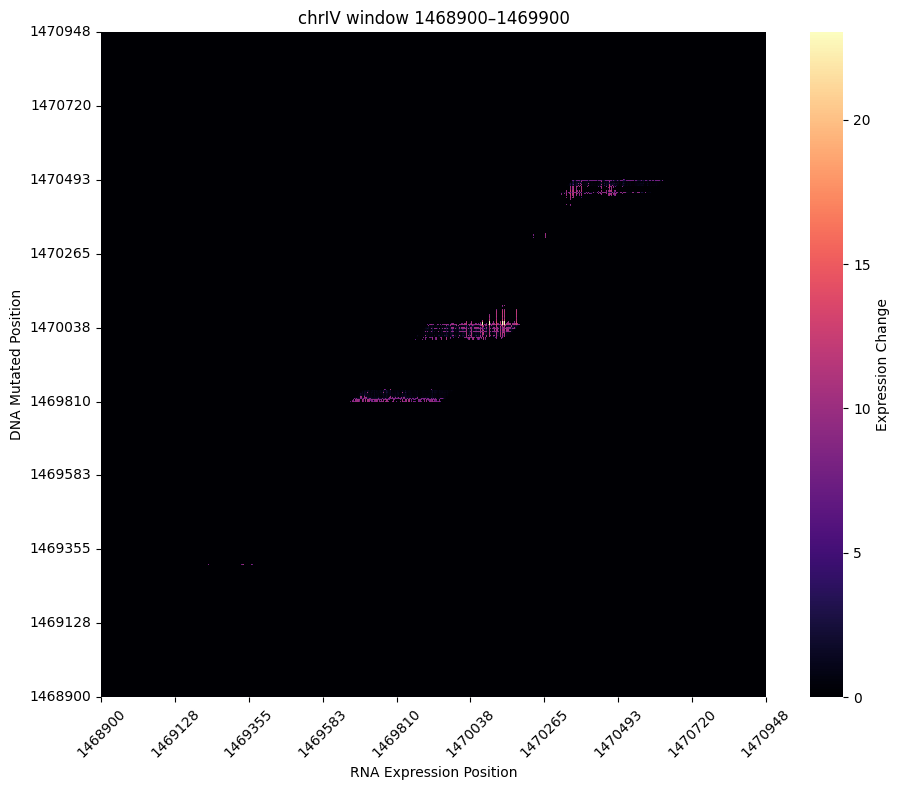

In [ ]:
plot_influence_matrix(influence_matrix_iv, start_position=1468900, title="chrIV window 1468900–1469900")


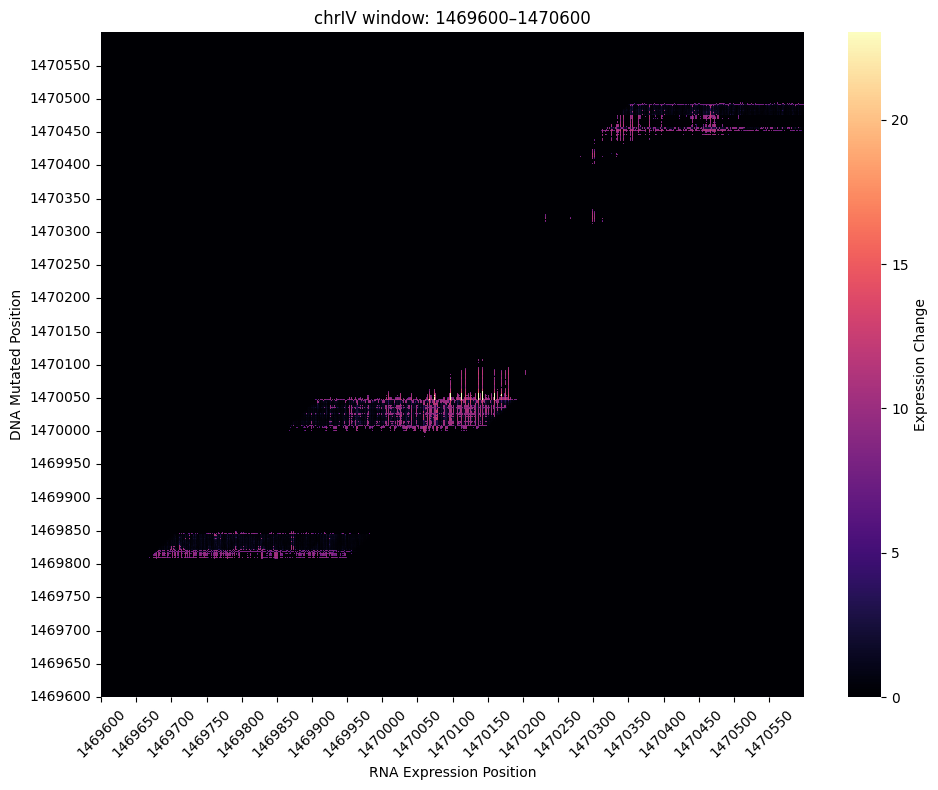

In [ ]:
plot_focused_mutagenesis_matrix(
    influence_matrix=influence_matrix_iv,
    genomic_start=1468900,
    focus_start=1469600,
    focus_end=1470600,
    title_prefix="chrIV window"
)


### Matrix for chrIX:47250..48250

In [ ]:
x_input_ix = sample_ix_idx[0].unsqueeze(0).to(device)     # (1, L, 6)
rna_mask_ix = sample_ix_idx[2].unsqueeze(0).to(device)    # (1, L)

influence_matrix_ix = in_silico_mutagenesis_matrix(
    model=model,
    original_seq_tensor=x_input_ix,
    expression_mask=rna_mask_ix,
    device=device
)

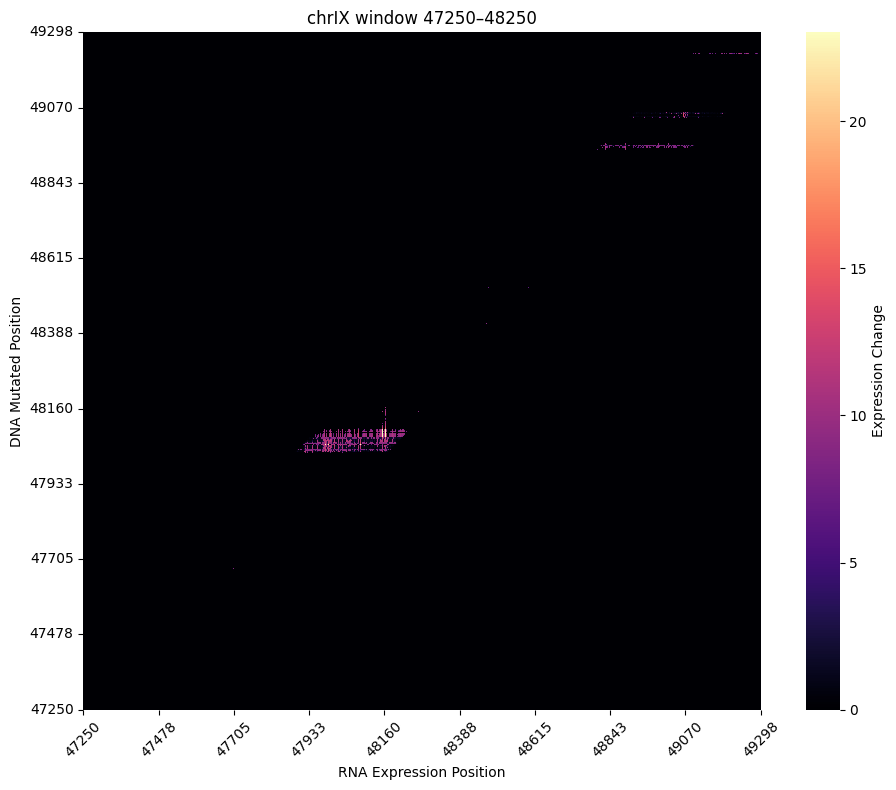

In [ ]:
plot_influence_matrix(influence_matrix_ix, start_position=47250, title="chrIX window 47250–48250")

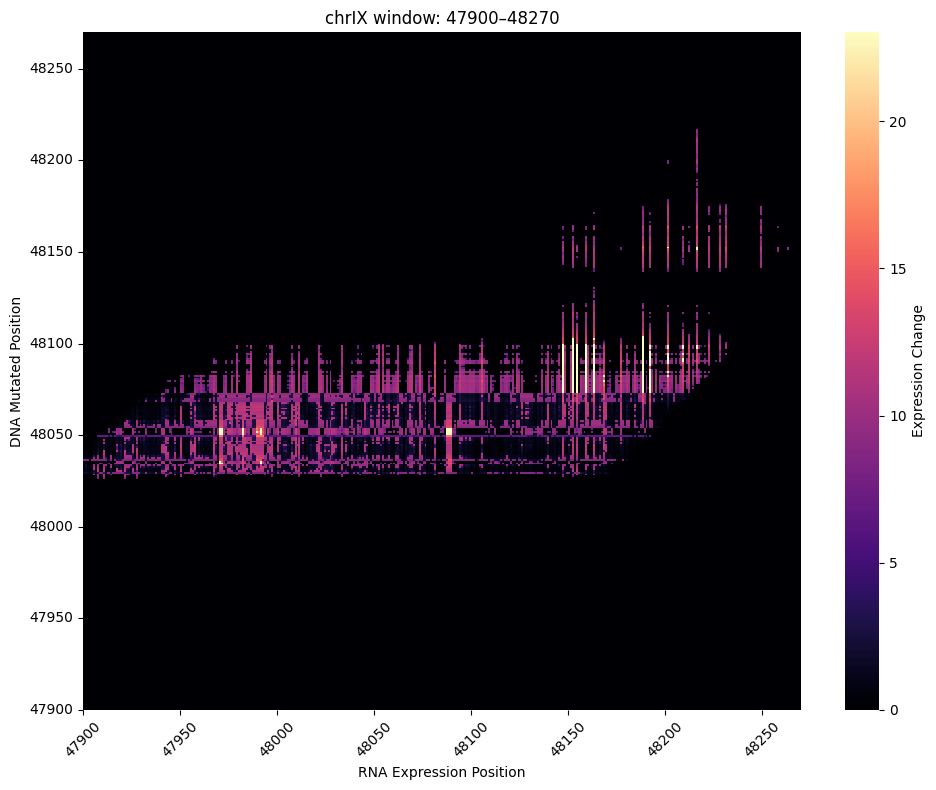

In [ ]:
plot_focused_mutagenesis_matrix(
    influence_matrix=influence_matrix_ix,
    genomic_start=47250,
    focus_start=47900,
    focus_end=48270,
    title_prefix="chrIX window"
)


## Calibration Plots

In [ ]:
def dna_calibration_plot_separate(model, dataloader, num_bins=10, sample_size=100):
    model.eval()
    all_preds = {nt: [] for nt in range(4)}  # 0:A, 1:C, 2:G, 3:T
    all_true  = {nt: [] for nt in range(4)}
    collected = 0

    with torch.no_grad():
        for batch in dataloader:
            x, _, _, mask_dna, dna_target = batch
            x = x.to(next(model.parameters()).device)
            mask_dna = mask_dna.to(torch.bool)
            dna_target = dna_target

            _, dna_logits = model(x)
            probs = torch.softmax(dna_logits, dim=-1)

            for nt in range(4):
                nt_probs = probs[..., nt][mask_dna].cpu().numpy()
                nt_true  = (dna_target[mask_dna] == nt).cpu().numpy()

                all_preds[nt].extend(nt_probs)
                all_true[nt].extend(nt_true)

            collected += x.size(0)
            if collected >= sample_size:
                break

    # Plot: 4 subplots (one per nucleotide)
    base_labels = ['A', 'C', 'G', 'T']
    base_colors = ['blue', 'orange', 'green', 'red']
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for nt in range(4):
        y_prob = np.array(all_preds[nt])
        y_true = np.array(all_true[nt])

        ax = axes[nt]
        if len(y_true) == 0 or y_true.sum() == 0:
            ax.set_title(f"{base_labels[nt]} – Not enough positive samples")
            ax.axis('off')
            continue

        frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=num_bins, strategy='uniform')
        ax.plot(mean_pred, frac_pos, label=f'{base_labels[nt]}', color=base_colors[nt], marker='o')
        ax.plot([0, 1], [0, 1], 'k--', label='Ideal')

        ax.set_title(f"Calibration for {base_labels[nt]}")
        ax.set_xlabel("Mean predicted probability")
        ax.set_ylabel("True frequency")
        ax.legend()
        ax.grid(True)

    plt.suptitle("DNA Calibration Plots per Nucleotide", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


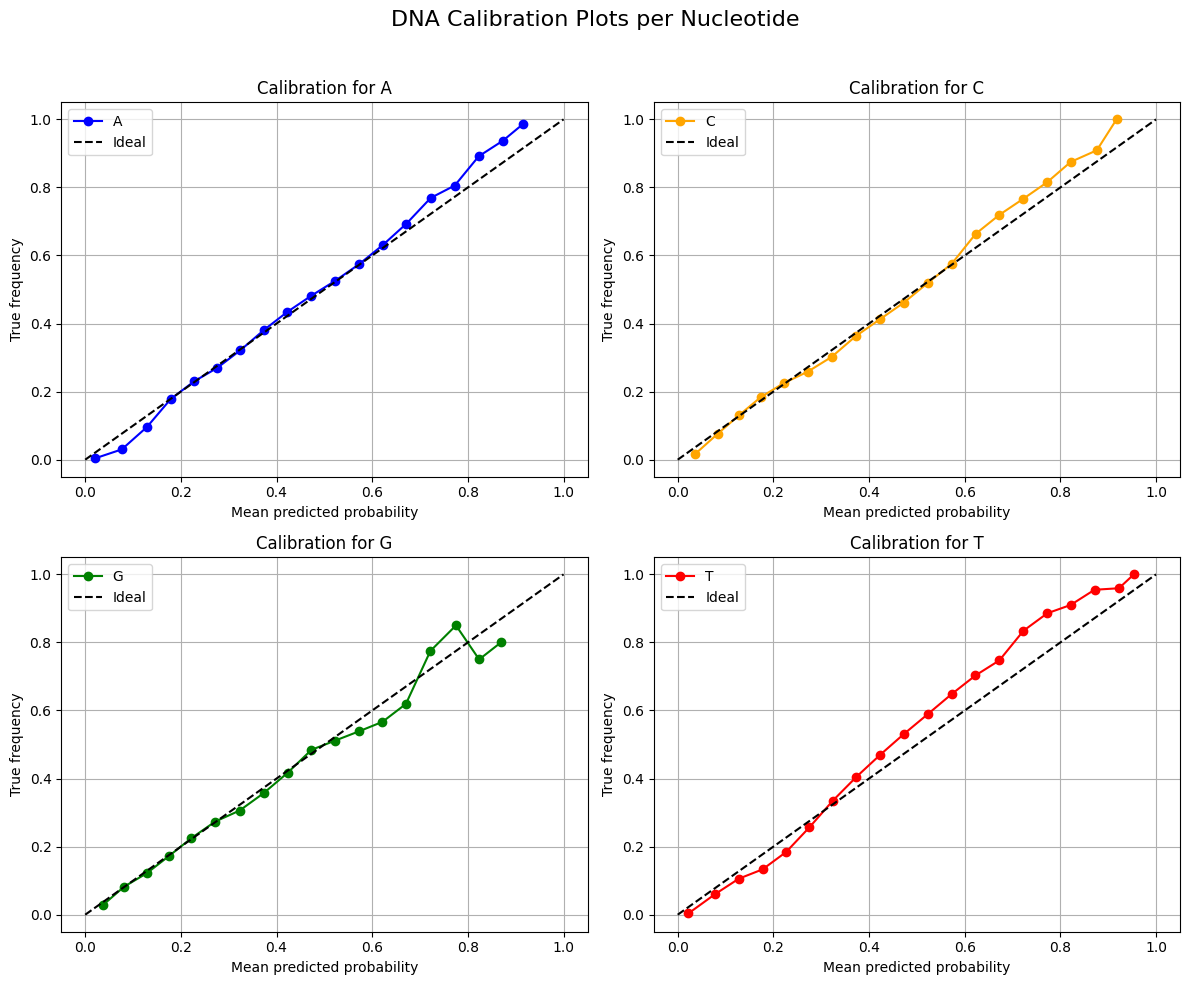

In [ ]:
dna_calibration_plot_separate(model, test_loader, num_bins=20, sample_size=4000)
